In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Load the dataset
df = pd.read_csv("C:\\Users\\Min\\Desktop\\BI Lab\\Lab 3\\ikea_kommun_data.txt", 
                 sep='\t', 
                 quotechar='"', 
                 encoding='latin1')

# Preview
print(df.head())
print("\nData types:\n", df.dtypes)

# Check data types
df.dtypes

# Drop categorical or textual columns
df_num = df.drop(columns=['Kommun_code', 'Year', 'Kommun_name'])

# Optional: check for any missing values
print("Missing values:\n", df_num.isnull().sum())

# Double-check the numeric data
print(df_num.describe())


# Drop rows with missing values (if any)
df_num = df_num.dropna()

# Keep a copy of original df for later merging
df_orig = df.copy()




   Kommun_code  Year     Kommun_name  Revenue  Employee  Population  \
0         2583  2010       Haparanda     1078       276       10059   
1          880  2010          Kalmar     3790      1621       62815   
2         1780  2010        Karlstad     4560      1910       85753   
3          114  2010  Upplands Väsby     1366       708       39289   
4          115  2010      Vallentuna      171        99       30114   

   Population_University  Percent_University  Productivity  SalesIndex  \
0                    719            0.071478     195.74174  111.075774   
1                   8716            0.138757     117.17365  390.516869   
2                  13308            0.155190     119.64794  469.856708   
3                   4419            0.112474      96.69215  140.750935   
4                   3843            0.127615      86.56347   17.619627   

   Infrast  Border  
0        0       1  
1        0       0  
2        0       0  
3        0       0  
4        0       0  

D

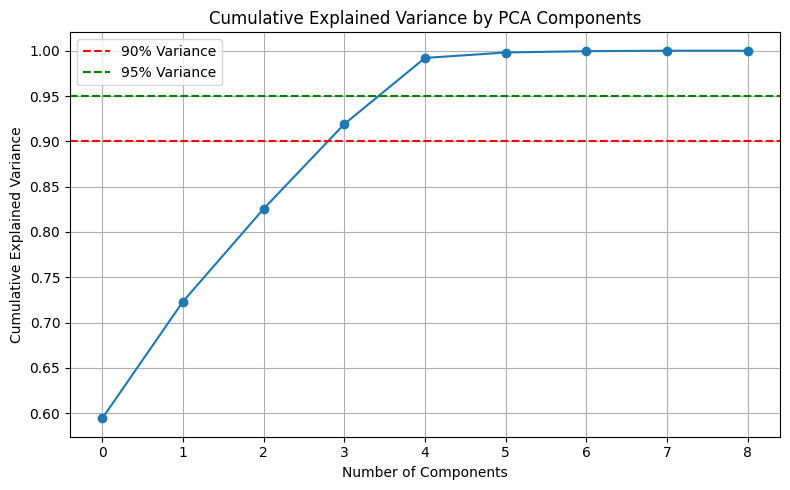

In [6]:
# To Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

# To Apply PCA
pca = PCA()
pca_components = pca.fit_transform(df_scaled)

# To Plot explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(explained_variance, marker='o')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# To Re-run PCA with 4 components (covers >95% variance)
pca_final = PCA(n_components=4)
df_pca = pca_final.fit_transform(df_scaled)

# Convert to DataFrame for inspection
df_pca_df = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(4)])
print(df_pca_df.head())


        PC1       PC2       PC3       PC4
0 -0.442137  6.220053 -0.046862 -0.486328
1  1.748724  0.382760 -1.056933  0.397704
2  2.457948  0.387208 -1.303152  0.354918
3  0.243091 -0.066118 -0.469815  0.106233
4 -0.325750 -0.412781 -0.566916 -0.065218


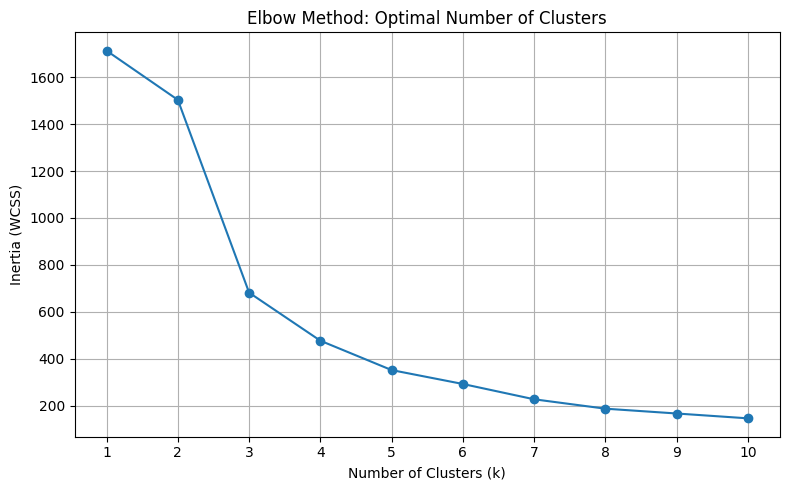

In [8]:
# Elbow method to determine optimal k
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method: Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.xticks(K_range)
plt.tight_layout()
plt.show()


In [9]:
# Apply k-means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_pca)

# Add cluster labels to PCA DataFrame and original DataFrame
df_pca_df['Cluster'] = clusters
df_orig['Cluster'] = clusters

# Show how many municipalities per cluster
print(df_orig['Cluster'].value_counts())


Cluster
1    173
0     33
2      1
Name: count, dtype: int64


In [33]:
# Mark IKEA store cities
df_orig['has_ikea'] = df_orig['Kommun_name'].isin(ikea_stores).astype(int)

# Automatically select top 3 candidate cities WITHOUT IKEA based on SalesIndex (or your metric)
top_candidates = (
    df_orig[df_orig['has_ikea'] == 0]        # Exclude IKEA cities
    .nlargest(3, 'SalesIndex')              # Replace with your desired metric
    ['Kommun_name']
    .tolist()
)



# Add 'has_ikea' column
df_orig['has_ikea'] = df_orig['Kommun_name'].apply(lambda x: 1 if x in ikea_stores else 0)

# Preview the new column
print(df_orig[['Kommun_name', 'has_ikea']].head())


      Kommun_name  has_ikea
0       Haparanda         1
1          Kalmar         1
2        Karlstad         1
3  Upplands Väsby         0
4      Vallentuna         0


   Cluster     Population       Revenue   SalesIndex      Employee
0        0   89434.000000   3575.424242   368.407251   1642.636364
1        1   19376.231214    362.410405    37.342316    203.855491
2        2  847073.000000  32897.000000  3389.665819  18795.000000


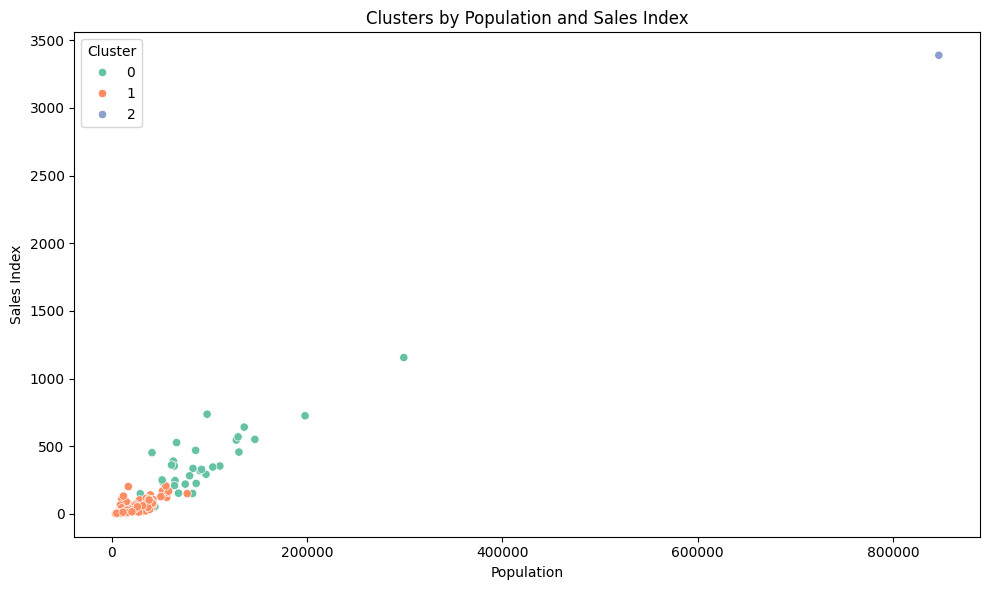

In [39]:
# Group by cluster and calculate summary statistics (mean)
cluster_summary = df_orig.groupby('Cluster').agg({
    'Population': 'mean',
    'Revenue': 'mean',
    'SalesIndex': 'mean',
    'Employee': 'mean'
}).reset_index()

print(cluster_summary)

# Visualize the clusters by key features (Population vs. SalesIndex)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Population', y='SalesIndex', hue='Cluster', data=df_orig, palette='Set2')
plt.title('Clusters by Population and Sales Index')
plt.xlabel('Population')
plt.ylabel('Sales Index')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


In [40]:
# Filter out municipalities with existing IKEA stores
potential_stores = df_orig[df_orig['has_ikea'] == 0]

# Sort by population and sales index (can adjust the weights as needed)
top_candidates = potential_stores.sort_values(by=['Population', 'SalesIndex'], ascending=False).head(7)

print("Top 7 candidates for new IKEA stores:\n", top_candidates[['Kommun_name', 'Population', 'SalesIndex']])

from sklearn.preprocessing import MinMaxScaler

# Filter out municipalities with existing IKEA stores
potential_stores = df_orig[df_orig['has_ikea'] == 0].copy()

# Normalize Population and SalesIndex using MinMaxScaler
scaler = MinMaxScaler()
potential_stores[['Population_norm', 'SalesIndex_norm']] = scaler.fit_transform(
    potential_stores[['Population', 'SalesIndex']]
)

# Create a combined IKEA_Score using weighted average:
# 60% weight to population (to prioritize cities with larger potential customer base)
# 40% weight to sales index (to account for economic activity and demand level)
# These weights can be adjusted based on IKEA’s strategic priorities or market demand
potential_stores['IKEA_Score'] = 0.6 * potential_stores['Population_norm'] + 0.4 * potential_stores['SalesIndex_norm']


# Sort by the combined IKEA_Score
top_candidates = potential_stores.sort_values(by='IKEA_Score', ascending=False).head(3)

# Print results
print("Top 3 Candidate Cities for New IKEA Stores (Ranked by Combined Score):\n")
for i, row in top_candidates.iterrows():
    print(f"{i+1}. {row['Kommun_name']} - Population: {row['Population']}, Sales Index: {row['SalesIndex']}, Score: {row['IKEA_Score']:.3f}")



Top 7 candidates for new IKEA stores:
     Kommun_name  Population  SalesIndex
53   Norrköping      130050  457.285981
118        Lund      110488  354.247229
173       Borås      103294  346.725400
9      Huddinge       97453  737.036192
42   Eskilstuna       96311  293.042210
130    Halmstad       91800  329.311851
21        Nacka       90108  319.832286
Top 3 Candidate Cities for New IKEA Stores (Ranked by Combined Score):

54. Norrköping - Population: 130050, Sales Index: 457.285981, Score: 0.848
10. Huddinge - Population: 97453, Sales Index: 737.036192, Score: 0.845
119. Lund - Population: 110488, Sales Index: 354.247229, Score: 0.699


In [41]:
!pip install geopy

from geopy.geocoders import Nominatim

# Initialize geocoder
geolocator = Nominatim(user_agent="ikea_clusters")

# Initialize geocoder with a timeout parameter
geolocator = Nominatim(user_agent="ikea_clusters", timeout=10)  # Timeout set to 10 seconds

# Function to geocode a municipality
def geocode_municipality(name):
    location = geolocator.geocode(name + ", Sweden")
    if location:
        return location.latitude, location.longitude
    return None, None  # In case geocoding fails

# Geocode the top 3 candidates
top_candidates_coords = []
for name in top_candidates['Kommun_name']:
    lat, lon = geocode_municipality(name)
    top_candidates_coords.append((name, lat, lon))

# Show the coordinates
print("Geocoded top 3 candidates:\n", top_candidates_coords)

import folium

# Create a base map (centered around Sweden's rough location)
m = folium.Map(location=[60.128161, 18.643501], zoom_start=6)

# Add markers for the top 3 municipalities
for name, lat, lon in top_candidates_coords:
    folium.Marker(
        location=[lat, lon],
        popup=f"{name}",
        icon=folium.Icon(color='blue')
    ).add_to(m)

# Save the map to an HTML file
m.save('ikea_top_3_candidates_map.html')

# Display the map (in Jupyter or IPython environment, use m)
m




[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Geocoded top 3 candidates:
 [('Norrköping', 58.5909124, 16.1903511), ('Huddinge', 59.216667, 18.0), ('Lund', 55.7029296, 13.1929449)]


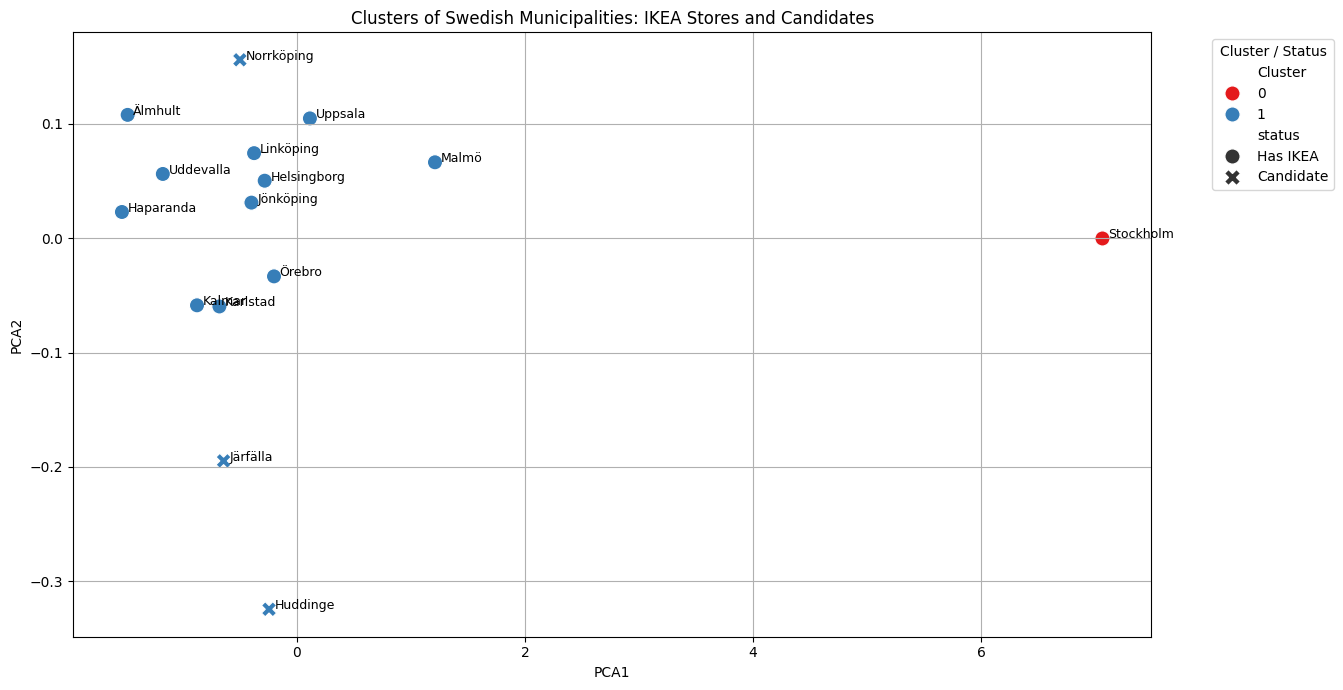


Nearest IKEA store distances (in PCA space):
   Kommun_name nearest_ikea  pca_distance_to_ikea
7     Järfälla     Karlstad              0.140007
9     Huddinge       Örebro              0.294439
53  Norrköping    Linköping              0.148530


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Flag IKEA cities and candidate cities
df_orig['has_ikea'] = df_orig['Kommun_name'].isin(ikea_stores).astype(int)

# Assume this list is already computed earlier (do not redefine)
top_candidate_names = top_candidates  # e.g. ['Lund', 'Norrköping', 'Täby']
df_orig['is_candidate'] = df_orig['Kommun_name'].isin(top_candidate_names).astype(int)

# Filter to IKEA cities and candidates only
df_focus = df_orig[(df_orig['has_ikea'] == 1) | (df_orig['is_candidate'] == 1)].copy()

#  Feature scaling
features = ['Population', 'Revenue', 'SalesIndex', 'Employee']
scaler = StandardScaler()
df_focus_scaled = scaler.fit_transform(df_focus[features])

# KMeans Clustering 
kmeans = KMeans(n_clusters=2, random_state=42)
df_focus['Cluster'] = kmeans.fit_predict(df_focus_scaled)

# PCA transformation
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_focus_scaled)
df_focus['PCA1'] = df_pca[:, 0]
df_focus['PCA2'] = df_pca[:, 1]

# Label status for plotting
df_focus['status'] = df_focus.apply(
    lambda row: 'Has IKEA' if row['has_ikea'] == 1 else ('Candidate' if row['is_candidate'] == 1 else 'Other'),
    axis=1
)

#  Plot clusters and city names 
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    style='status',
    data=df_focus,
    palette='Set1',
    s=120
)

# Add city labels
for i in range(df_focus.shape[0]):
    plt.text(
        df_focus['PCA1'].iloc[i] + 0.05,
        df_focus['PCA2'].iloc[i],
        df_focus['Kommun_name'].iloc[i],
        fontsize=9
    )

plt.title('Clusters of Swedish Municipalities: IKEA Stores and Candidates')
plt.grid(True)
plt.tight_layout()
plt.legend(title='Cluster / Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Compute distances between each candidate and the nearest IKEA city (in PCA space) ---
candidates = df_focus[df_focus['is_candidate'] == 1].copy()
ikea_cities = df_focus[df_focus['has_ikea'] == 1].copy()

# Calculate pairwise Euclidean distances in PCA space
distances = cdist(candidates[['PCA1', 'PCA2']], ikea_cities[['PCA1', 'PCA2']], metric='euclidean')
min_dist_idx = distances.argmin(axis=1)
min_dist_val = distances[np.arange(len(candidates)), min_dist_idx]

# Annotate candidates with nearest IKEA info
candidates['nearest_ikea'] = ikea_cities.iloc[min_dist_idx]['Kommun_name'].values
candidates['pca_distance_to_ikea'] = min_dist_val

# Merge back to df_focus
df_focus = df_focus.drop(columns=['nearest_ikea', 'pca_distance_to_ikea'], errors='ignore')  # Clean old values
df_focus = df_focus.merge(
    candidates[['Kommun_name', 'nearest_ikea', 'pca_distance_to_ikea']],
    on='Kommun_name',
    how='left'
)

# Show distance info
print("\nNearest IKEA store distances (in PCA space):")
print(candidates[['Kommun_name', 'nearest_ikea', 'pca_distance_to_ikea']])



In [ ]:
# To Add commentary based on PCA distance
most_potential = candidates.sort_values(by='pca_distance_to_ikea', ascending=False).iloc[0]
print(f"\nRecommendation based on PCA distance:")
print(f"   {most_potential['Kommun_name']} is the most distant from the nearest IKEA store in PCA space.")
print(f"   This suggests it could be the best candidate for a new IKEA location.")



Recommendation based on PCA distance:
   Huddinge is the most distant from the nearest IKEA store in PCA space.
   This suggests it could be the best candidate for a new IKEA location.
